In [1]:
# import time
# from tqdm.notebook import tqdm
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
from h5 import HDFArchive

from triqs.atom_diag import AtomDiagComplex
from triqs.operators import n, c, c_dag
from itertools import product
from triqs.plot.mpl_interface import oplot, plt
from triqs.utility.comparison_tests import *

import sys
sys.path.append('../')

from sort import sort_states_full
from three_pt_corr import *
from four_pt_corr import *
from four_pt_corr_v2 import FourPtCorr as FourPtCorr_v2

from itertools import product

In [222]:
# Number of bosonic Matsubara frequencies for susceptibility calculation
bn_iw = 10
# Number of fermionic Matsubara frequencies for susceptibility calculation
fn_iw = 10

beta = 2.0             # Inverse temperature

biw_mesh = MeshImFreq(beta = beta, statistic = 'Boson', n_iw = bn_iw)
fiw_mesh = MeshImFreq(beta = beta, statistic = 'Fermion', n_iw = fn_iw)

In [223]:
# Hubbard dimer

####################
# Input parameters #
####################

eps = [-1.9, -2.1]      # Energy levels of the atoms
t = 0.5                 # Hopping matrix element
U = 4.0                 # Coulomb repulsion
h_field = 0.05          # Magnetic field

spin_names = ("up", "dn")
atoms = (0, 1)

H = sum(e * n(s, a) for (a, e), s in product(zip(atoms, eps), spin_names))
H += sum(-h_field * (n('up', a) - n('dn', a)) for a in atoms)
H += U * sum(n('up', a) * n('dn', a) for a in atoms)
H += t * sum((c_dag(sp, 0) * c(sp, 1) + c_dag(sp, 1) * c(sp, 0)) for sp in spin_names)

fops = list(product(spin_names, atoms))

In [224]:
ad = AtomDiagComplex(H, fops)
print(ad.gs_energy)

-4.236567364479854


In [225]:
eigensys = sort_states_full(spin_names, atoms, ad)

states in subspace  0 : 
| 0101 >
| 0110 >
| 1001 >
| 1010 >
states in subspace  1 : 
| 0011 >
states in subspace  2 : 
| 1100 >
states in subspace  3 : 
| 0001 >
| 0010 >
states in subspace  4 : 
| 0111 >
| 1011 >
states in subspace  5 : 
| 0100 >
| 1000 >
states in subspace  6 : 
| 1101 >
| 1110 >
states in subspace  7 : 
| 0000 >
states in subspace  8 : 
| 1111 >
Finished sorting states


In [226]:
# for n in range(len(eigensys)):
#     print(eigensys[n][1])

# 3 Point Function

In [252]:
# from importlib import reload

# import three_pt_corr
# reload(three_pt_corr)

# from three_pt_corr import *

## <c_dag(t1)c(t1)c_dag(t_2)c(0)>

In [8]:
%%time

G_iw = dict()
for x, y, z, w in product(range(2),repeat=4):
    ops = [(c_dag('up', x)*c('up', y), 'Boson'),
           (c_dag('up',z), 'Fermion'),
           (c('up', w), 'Fermion')]
    
    corr = ThreePtCorr(ops = ops, hamiltonian = (ad, eigensys))
    
    # G = corr.G_div_diff_iw(beta = beta, n_iw = [10,10])
    G_iw[f'%i%i%i%i'%(x, y, z, w)] = corr.G_div_diff_iw(beta = beta, n_iw = [10,1000])
    

CPU times: user 5min 36s, sys: 431 ms, total: 5min 37s
Wall time: 5min 46s


In [9]:
with HDFArchive("ncdagc_10_1000_shift", 'w') as A:
    A['beta'] = beta
    A['chi3'] = G_iw
    A['spin'] = 'up up up up'

In [77]:
with HDFArchive("ncdagc_10_3000", 'r') as A:
    G_iw = A['chi3']
    beta = A['beta']

# Integrate over the first frequency
G_int1 = dict()
fiw_mesh = MeshImFreq(beta = beta, statistic = 'Fermion', n_iw = 3000)
for x, y, z, w in product(range(2),repeat=4):
    
    G = Gf(mesh = biw_mesh, target_shape = [])
    G.zero()
    
    for iw1 in biw_mesh:
        for iw2 in fiw_mesh:
            G[iw1] += G_iw[f'%i%i%i%i'%(x, y, z, w)][iw1,iw2]

    G_int1[f'%i%i%i%i'%(x, y, z, w)] = G


# oplot(G_int1['0000'])

## <c_dag(t1)c(t2)c_dag(0)c(0)>

In [228]:
%%time

G_iw = dict()
for x, y, z, w in product(range(2),repeat=4):
    ops = [(c_dag('up', x), 'Fermion'),
           (c('up',y), 'Fermion'),
           (c_dag('up', z)*c('up',w), 'Boson')]
    
    corr = ThreePtCorr(ops = ops, hamiltonian = (ad, eigensys))
    
    G = corr.G_div_diff_iw(beta = beta, n_iw = [10,10])
    G_iw[f'%i%i%i%i'%(x, y, z, w)] = G
    

CPU times: user 3.5 s, sys: 3.95 ms, total: 3.51 s
Wall time: 3.56 s


In [229]:
# Integrate over the first frequency
G_int1 = dict()

fiw_mesh = MeshImFreq(beta = beta, statistic = 'Fermion', n_iw = 10)
for x, y, z, w in product(range(2),repeat=4):
    
    G = Gf(mesh = fiw_mesh, target_shape = [])
    G.zero()
    
    for iw1 in fiw_mesh:
        for iw2 in fiw_mesh:
            G[iw1] += G_iw[f'%i%i%i%i'%(x, y, z, w)][iw1,iw2]

    G_int1[f'%i%i%i%i'%(x, y, z, w)] = G


# oplot(G_int1['0000'])

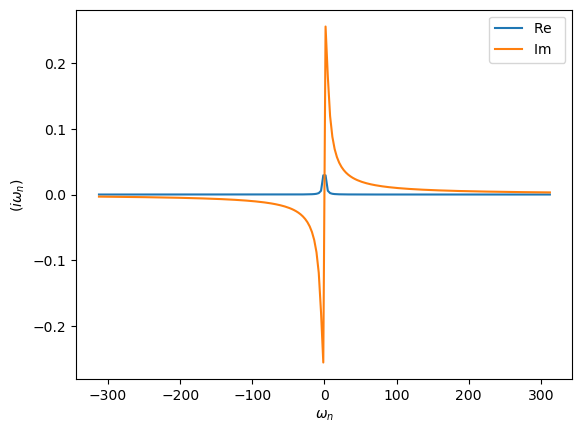

In [117]:
oplot(-G_int1['0000'])

In [23]:
div_diff = HDFArchive("dimer_chi3_div_diff.h5", 'w')

for x, y, z, w in product(range(2),repeat=4):
    div_diff["G_int1"] = G_int1

# Reference 2 Point Function Dimer

In [14]:
# ref = HDFArchive("pomerol_ref.h5", 'r')
# print(ref)

In [83]:
for n in range(len(eigensys)):
    print(eigensys[n][1])

0.0
0.13656736447985462
0.23656736447985516
0.3365673644798539
1.6766654131205758
1.6766654131205758
1.776665413120575
1.7766654131205755
2.696469315839133
2.696469315839133
2.7964693158391323
2.7964693158391327
4.127348401399195
4.236567364479854
4.236567364479854
4.582353692040369


In [84]:
for e in ref['energies']:
    print(e)

[0.]
[-2.45990195 -1.44009805]
[-2.55990195 -1.54009805]
[-4.23656736 -4.         -0.10921896  0.34578633]
[-3.9]
[-2.45990195 -1.44009805]
[-4.1]
[-2.55990195 -1.54009805]
[0.]


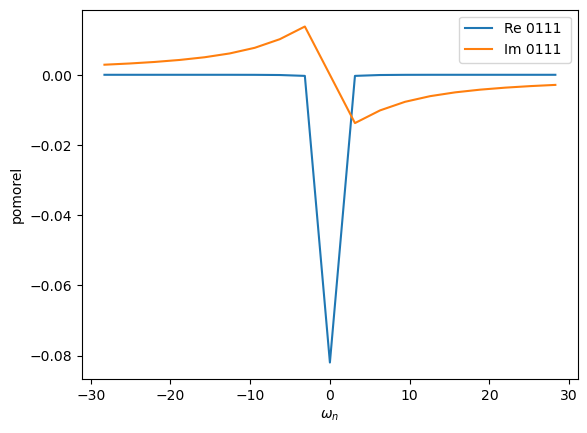

In [85]:
s = '0111'
oplot(ref[s], ylabel = 'pomorel')

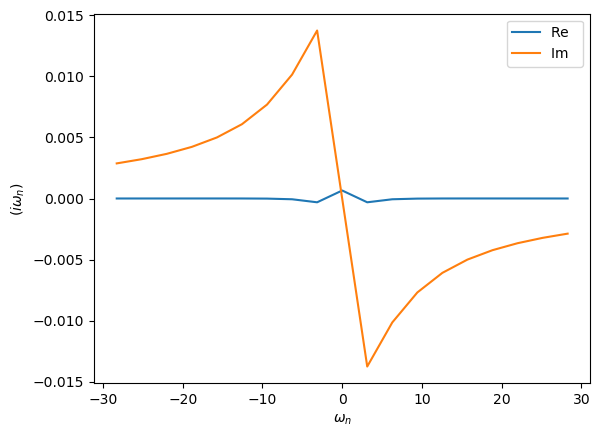

In [86]:
oplot(-G_int1[s]/beta)

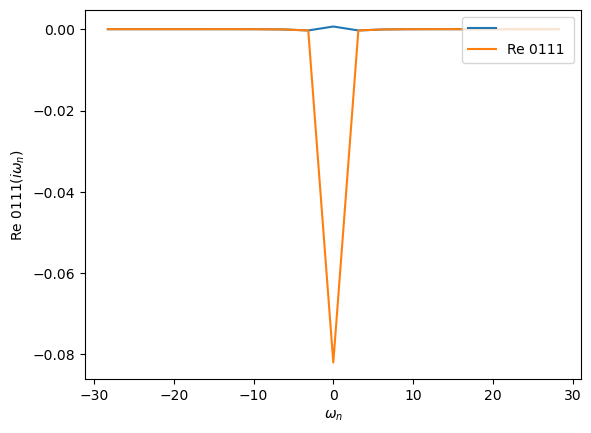

In [87]:
oplot(-G_int1[s].real/beta)
oplot(ref[s].real)

In [88]:
print(biw_mesh[8].value.value)
print(biw_mesh[10].value.value)
print(ref[s][biw_mesh[8]])
print(ref[s][biw_mesh[10]])

-34.55751918948772j
-28.274333882308138j


AssertionError: Green function Mesh and MeshPoint have incompatible hash

In [89]:
print(biw_mesh[8].value.value)
print(biw_mesh[10].value.value)
print(-G_int1[s][biw_mesh[8]]/beta)
print(-G_int1[s][biw_mesh[10]]/beta)

-34.55751918948772j
-28.274333882308138j


AssertionError: Green function Mesh and MeshPoint have incompatible hash

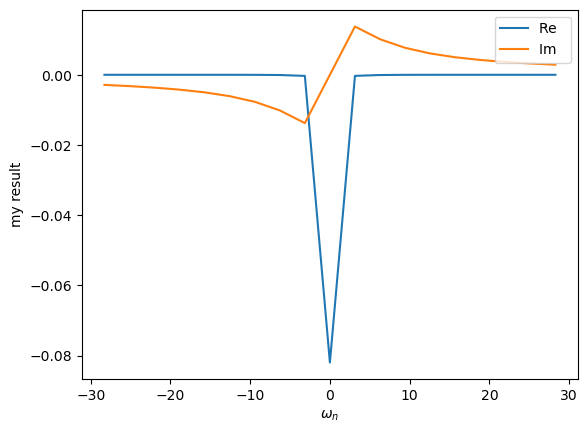

In [169]:
G = -G_int1[s].copy()/beta
G[biw_mesh[9]] = ref[s][biw_mesh[9]]
oplot(G, ylabel = 'my result')

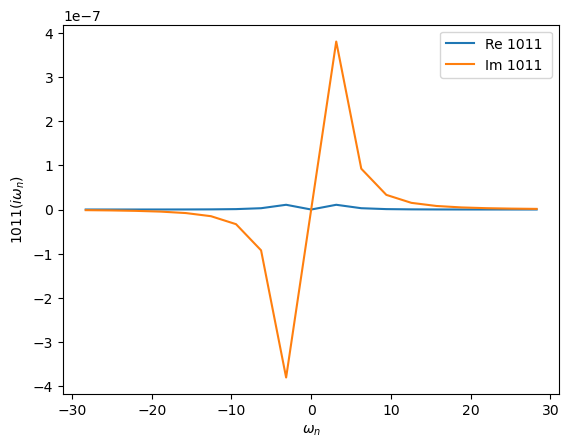

In [170]:
oplot(ref[s]-G)
# print((ref[s][biw_mesh[10]]+G_int1[s][biw_mesh[10]]/beta).real)

In [136]:
biw_mesh[9].value.value

0j

# Reference 3 Point Function Dimer

In [287]:
%%time 

ref = HDFArchive("pomerol_ref.h5", 'r')
print(type(ref["chi3_ph_AABB"]))

fiw_mesh = MeshImFreq(beta = beta, statistic = 'Fermion', n_iw = 50)
biw_mesh = MeshImFreq(beta = beta, statistic = 'Boson', n_iw = 50)

G_ref = ref['chi3_ph_AABB']["up","up"]

G_ref_int1 = dict()
for x, y, z, w in product(range(2),repeat=4):
    G = Gf(mesh = fiw_mesh, target_shape = [])
    G.zero()

    for iw2 in fiw_mesh:
        for iw1 in biw_mesh:
            G[iw2] += G_ref[x,y,z,w][iw1,iw2]

    G_ref_int1[f'%i%i%i%i'%(x, y, z, w)] = G

# oplot(-G_ref)

<class 'triqs.gf.block2_gf.Block2Gf'>
CPU times: user 2.23 s, sys: 3.03 ms, total: 2.23 s
Wall time: 2.28 s


In [235]:
# from triqs.gf import Idx

# ref = ref['chi3_ph_AABB']["up","up"]

# def pom_chi3(x, y, z, w, n1, n2):
#     """Pomerol's ThreePointSusceptibility at fermionic Matsubara integers n1, n2."""
#     return ref[x, y, z, w][Idx(n2 - n1), Idx(n1)]

In [237]:
N = 5


bindary_strings = [f"{i:04b}" for i in range(16)]
for s in bindary_strings:
    mine = np.array([[G_iw[s][Idx(a), Idx(b)] for b in range(-N, N)]
                                                for a in range(-N, N)])

    theirs = np.array([[G_ref[int(s[0]),int(s[1]),int(s[2]),int(s[3])][Idx(a+b+1), Idx(-a-1)] for b in range(-N,N)]
                                                            for a in range(-N,N)])
    print(np.abs(mine + theirs).max())
    
# print(np.abs(mine - theirs).max(), np.abs(theirs).max())
# print((mine / theirs)[np.abs(theirs) > 1e-12][:10])   # constant => normalization

3.7238012298709097e-16
5.677783658672699e-17
4.186428067025486e-17
1.2723933587929954e-16
4.654751537338637e-17
1.2146089072786933e-17
9.141618280377864e-17
2.4996915352160854e-17
8.355534721610418e-17
1.1180747838697866e-16
1.3034211866714157e-17
3.469446951953614e-17
1.1643341981219687e-16
5.2566701250553736e-17
4.5138006031235954e-17
2.9893669801409083e-16


In [283]:
fa = [p.index for p in G_iw['0000'].mesh[0]]
fb = [p.index for p in G_iw['0000'].mesh[1]]

for s in binary_strings:
    g_ref = G_ref[int(s[0]),int(s[1]),int(s[2]),int(s[3])]
    worst, n = 0.0, 0
    for W in g_ref.mesh[0]:
        for nu in g_ref.mesh[1]:
            a, b = -nu.index - 1, W.index + nu.index
            if a in fa and b in fb:
                d = abs(G_iw[s][Idx(a), Idx(b)] + g_ref[Idx(W.index), Idx(nu.index)])
                worst, n = max(worst, d), n + 1
    print(s, worst, n)

0000 3.7238012298709097e-16 290
0001 5.677783658672699e-17 290
0010 4.1864280670254864e-17 290
0011 1.2723933587929954e-16 290
0100 4.654751537338637e-17 290
0101 1.2146089072786933e-17 290
0110 9.141618280377864e-17 290
0111 2.4996915352160857e-17 290
1000 8.355534721610419e-17 290
1001 1.1180747838697866e-16 290
1010 1.3034211866714155e-17 290
1011 3.469446951953614e-17 290
1100 1.1643341981219687e-16 290
1101 5.2566701250553736e-17 290
1110 4.513800603123596e-17 290
1111 2.9893669801409083e-16 290


19

In [309]:
from triqs.gf import Idx

s = '0000'

g_ph_ref = G_ref[int(s[0]),int(s[1]),int(s[2]),int(s[3])]
g_ref = []

for iw1 in G_iw[s].mesh[0]:
    for iw2 in G_iw[s].mesh[1]:
        g_ref.append(g_ph_ref[Idx(iw1.index+iw2.index), Idx(-iw1.index-1)])

g_ref = np.array(g_ref)
g_ref = g_ref.reshape((len(G_iw[s].mesh[0]), len(G_iw[s].mesh[1])))
g = Gf(mesh = G_iw[s].mesh, data = g_ref)

assert_gfs_are_close(g, -G_iw[s])

AssertionError: Arrays are different. Difference is 0.511457306167864.
 [[-0.00101111-4.20572664e-07j -0.00111705-2.32022118e-21j
  -0.00124766+6.41066642e-07j -0.00141258+1.64537496e-06j
  -0.00162724+3.28163402e-06j -0.00191776+6.09894458e-06j
  -0.0023319 +1.13495540e-05j -0.00296636+2.23660269e-05j
  -0.00404376+5.03557522e-05j -0.00614169+1.51429251e-04j
  -0.00916896+8.84313646e-04j  0.0078787 +9.90215951e-04j
   0.00581373+2.10039640e-04j  0.00391039+8.68717248e-05j
   0.00289574+4.86921040e-05j  0.00228852+3.19000781e-05j
   0.00188851+2.29431968e-05j  0.00160632+1.75486473e-05j
   0.0013973 +1.40163215e-05j  0.00123972+1.15475638e-05j]
 [-0.00112927-1.05005068e-06j -0.00124766-6.41066642e-07j
  -0.00139362-1.89879704e-21j -0.00157796+1.02696866e-06j
  -0.00181793+2.73094012e-06j -0.00214278+5.70975008e-06j
  -0.00260604+1.13332054e-05j -0.00331609+2.32630001e-05j
  -0.00452297+5.38664453e-05j -0.00687783+1.65334139e-04j
  -0.01032103+9.80786092e-04j  0.00871138+1.11296327e-03j

In [295]:
G_iw[s].mesh

MeshProduct of :Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false, Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false

In [290]:
g_ph_ref[Idx(iw1.index+iw2.index), Idx(-iw1.index-1)]

np.complex128(-0.0012476569469740272-6.410666419110137e-07j)

In [277]:
print(biw_mesh[9].value.value)
print(biw_mesh[9].index)

print(fiw_mesh[20].value.value)
print(fiw_mesh[10].index)

0j
0
32.98672286269283j
0


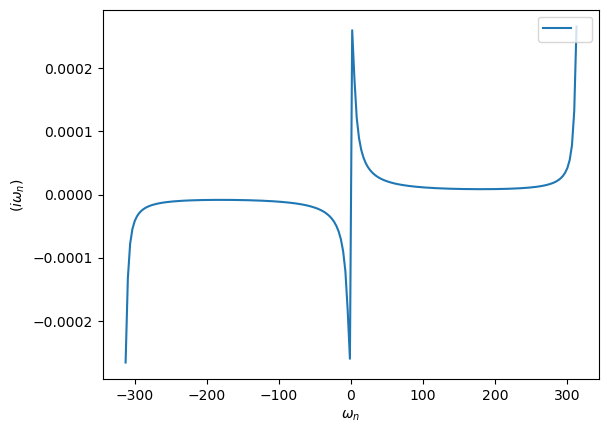

In [142]:
oplot(G_ref_int1['0010'].imag)

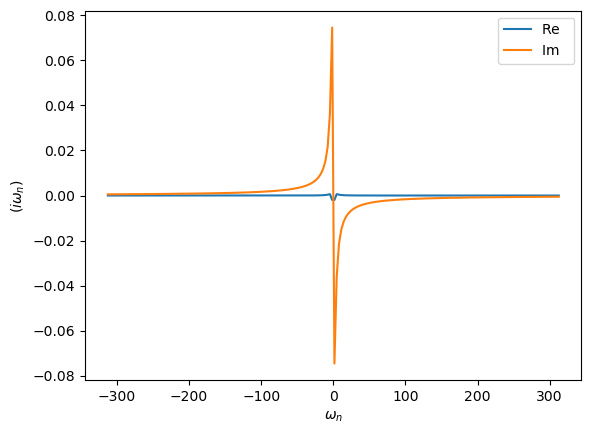

In [143]:
oplot(-G_int1['0001'])

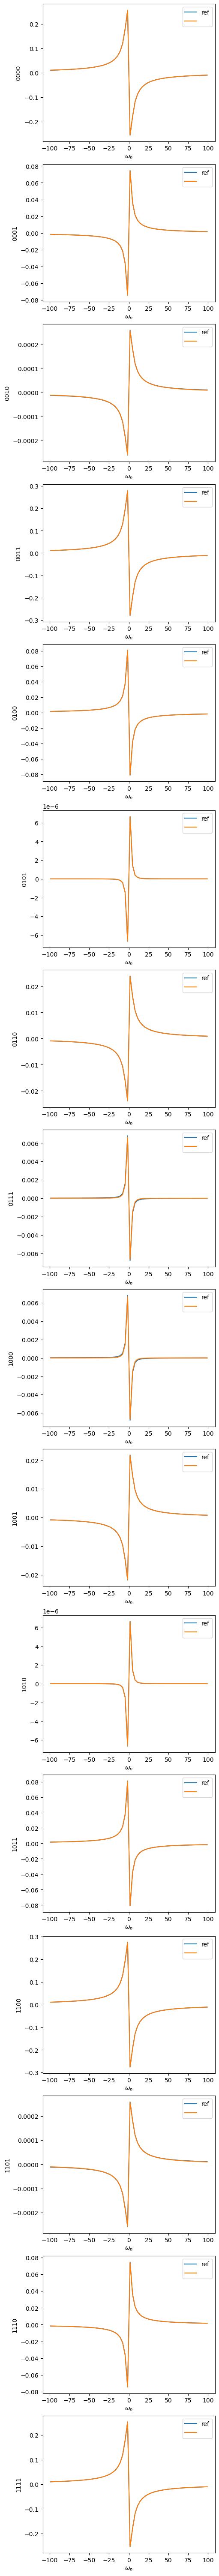

In [144]:
bindary_strings = [f"{i:04b}" for i in range(16)]
# abcd -> badc
swapped_strings = [f"{s[1]}{s[0]}{s[3]}{s[2]}" for s in binary_strings]

fig, axes = plt.subplots(16,1, figsize=(5, 60), layout="constrained")

for i in range(16):
    axes[i].oplot(G_ref_int1[bindary_strings[i]].imag, label='ref',x_window = (-100,100))
    axes[i].oplot(G_int1[binary_strings[i]].imag, x_window = (-100,100))
    axes[i].set_ylabel(f'{i:04b}')

In [137]:
# fiw_mesh = MeshImFreq(beta = beta, n_iw = 500, statistic='Fermion')
# G_ref_int1['0000'][fiw_mesh[0]].real

np.float64(0.00152611837143198)

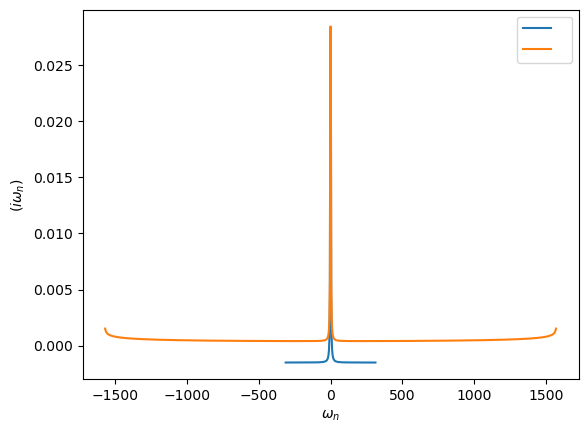

In [138]:
# G = G_int1['0000'].copy()
# G.zero()

# G << 0.0015

# oplot(-G_int1['0000'].real - G.real)
# oplot(G_ref_int1['0000'].real)

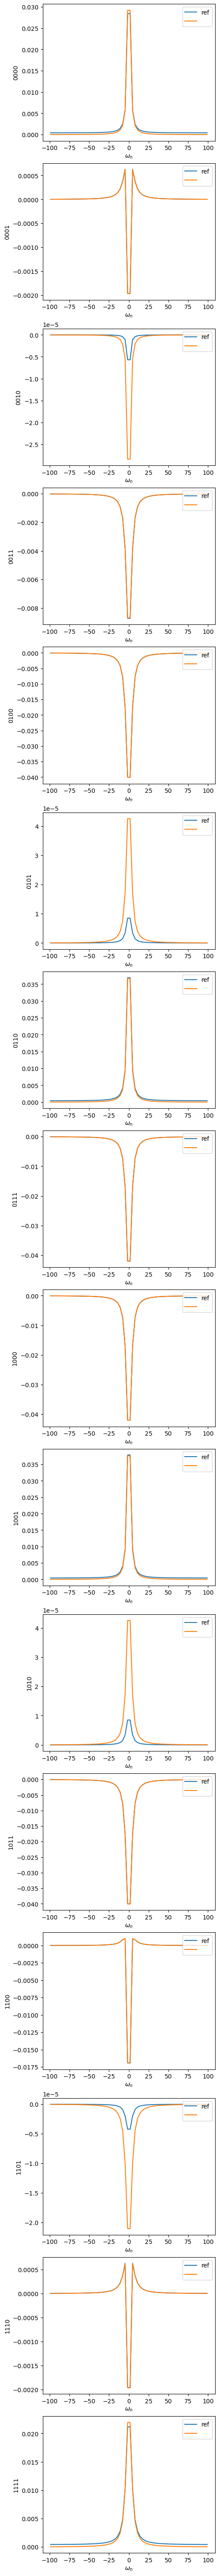

In [135]:
bindary_strings = [f"{i:04b}" for i in range(16)]
# abcd -> badc
# swapped_strings = [f"{s[1]}{s[0]}{s[3]}{s[2]}" for s in binary_strings]
swapped_strings = [f"{s[0]}{s[1]}{s[2]}{s[3]}" for s in binary_strings]

fig, axes = plt.subplots(16,1, figsize=(5, 60), layout="constrained")

for i in range(16):
    axes[i].oplot(G_ref_int1[bindary_strings[i]].real, label='ref', x_window = (-100,100))
    axes[i].oplot(-G_int1[swapped_strings[i]].real,x_window = (-100,100))
    axes[i].set_ylabel(f'{i:04b}')

In [29]:
binary_strings = [f"{i:04b}" for i in range(16)]
for s in binary_strings:
    assert_gfs_are_close(G_ref_int1[s].imag, -G_int1[s].imag, precision = 1e-3)

AssertionError: Arrays are different. Difference is 0.0719964386743298.
 [-0.00251617 -0.00268217 -0.00285716 -0.00304482 -0.00325208 -0.00348508
 -0.00375069 -0.00405743 -0.00441653 -0.00484336 -0.0053597  -0.00599758
 -0.00680632 -0.00786598 -0.00931592 -0.01142232 -0.01476455 -0.02087493
 -0.03521468 -0.07328982  0.07328982  0.03521468  0.02087493  0.01476455
  0.01142232  0.00931592  0.00786598  0.00680632  0.00599758  0.0053597
  0.00484336  0.00441653  0.00405743  0.00375069  0.00348508  0.00325208
  0.00304482  0.00285716  0.00268217  0.00251617] 

 --------- 

 [-7.85663559e-05 -8.57568468e-05 -9.13902683e-05 -9.71907852e-05
 -1.03571828e-04 -1.10760159e-04 -1.18973090e-04 -1.28471498e-04
 -1.39595638e-04 -1.52808556e-04 -1.68761948e-04 -1.88405289e-04
 -2.13177974e-04 -2.45369214e-04 -2.88842934e-04 -3.50633709e-04
 -4.44865574e-04 -6.03624994e-04 -9.07233814e-04 -1.29337977e-03
  1.29337977e-03  9.07233814e-04  6.03624994e-04  4.44865574e-04
  3.50633709e-04  2.88842934e-04  

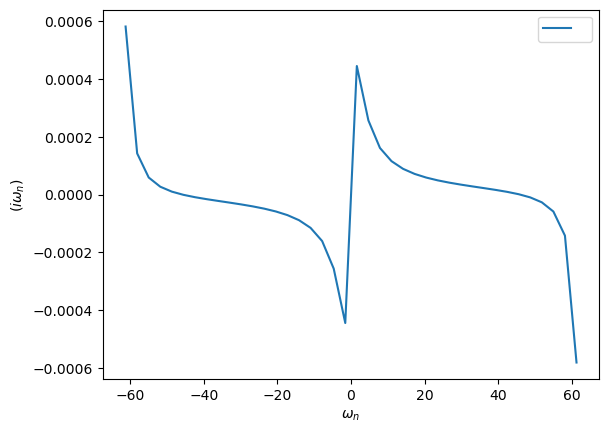

In [17]:
oplot(G_ref.imag+G_int1['0000'].imag)
# oplot(-G_int1['0000'].imag)
# oplot(G_ref.imag)

In [207]:
G_ref[fiw_mesh[9]].real+G_int1['0000'][fiw_mesh[9]].real

np.float64(0.00916896436805685)

In [28]:
ref2 = HDFArchive("dimer_chi3.ref.h5", 'r')
print(ref2)

HDFArchive (partial view) with the following content:
  H : data 
  chi3_ph_AABB : subgroup
  chi3_ph_ABBA : subgroup
  chi3_pp_AABB : subgroup
  chi3_pp_ABBA : subgroup
  chi3_xph_AABB : subgroup
  chi3_xph_ABBA : subgroup


# 4 Point Function

In [26]:
%%time

ops = [(c_dag('up', 0), 'Fermion'),
       (c('up',0), 'Fermion'),
       (c('up', 0), 'Fermion'),
       (c_dag('up', 0), 'Fermion')]

corr = FourPtCorr(ops = ops, hamiltonian = (ad, eigensys))

G = corr.G_div_diff_iw(beta = beta, n_iw = [5,5,5])

start numerical calculations
CPU times: user 1min 5s, sys: 174 ms, total: 1min 5s
Wall time: 1min 5s


In [55]:
%%time

ops = [(c_dag('up', 0), 'Fermion'),
       (c('up',0), 'Fermion'),
       (c('up', 0), 'Fermion'),
       (c_dag('up', 0), 'Fermion')]

corr = FourPtCorr_v2(ops = ops, hamiltonian = (ad, eigensys))

G = corr.G_div_diff_iw(beta = beta, n_iw = [5,5,5])

start numerical calculations
CPU times: user 17.1 s, sys: 41 ms, total: 17.2 s
Wall time: 17.3 s


In [61]:
A = HDFArchive("plaq_4pt.h5", 'r')
print(A["G"].mesh)

Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false, Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false, Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false


In [2]:
import numpy as np